In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/8vo/data/Flowers"
!pwd

Mounted at /content/drive
/content/drive/MyDrive/8vo/data/Flowers
/content/drive/MyDrive/8vo/data/Flowers


### Primer modelo

In [ ]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, GlobalAveragePooling2D, Dropout
import json
from tensorflow.keras.callbacks import ModelCheckpoint


In [ ]:
# Carga del dataset
base_dir = '/content/drive/MyDrive/8vo/data/Flowers'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'val') # Le puse test pq el chino que hizo el ds lo separó con el nombre val, pero es test

class_names = sorted(os.listdir(train_dir))
print(f"Clases ({len(class_names)}):", class_names)

Clases (14): ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [ ]:
IMG_SIZE = (256, 256)

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir+"/train",
    image_size = IMG_SIZE,
    color_mode="rgb",
    batch_size = 10,
    shuffle = True,
    validation_split = 0.2,
    subset = "training",
    seed = 123
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir+"/train",
    image_size = IMG_SIZE,
    color_mode="rgb",
    batch_size = 10,
    shuffle = True,
    validation_split = 0.2,
    subset = "validation",
    seed = 123
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = 10,
    shuffle = True,
)


Found 13642 files belonging to 14 classes.
Using 10914 files for training.
Found 13642 files belonging to 14 classes.
Using 2728 files for validation.
Found 98 files belonging to 14 classes.


### Escalamiento de las imagenes y preprocesado (Data augmentation)

In [ ]:
augment_rotation = tf.keras.layers.RandomRotation(0.3)

def AugmentAndScale(image, label):
    image = tf.cond(
        tf.reduce_max(image) > 1.0,
        lambda: image / 255.0,
        lambda: image
    )
    # Data Augmentation
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_flip_left_right(image)
    image = augment_rotation(image, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

train_ds = train_ds.map(AugmentAndScale)
validation_ds = validation_ds.map(AugmentAndScale)
test_ds  = test_ds.map(AugmentAndScale)


print(train_ds)

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os


class_names = sorted(os.listdir(train_dir))
class_counts = np.array([
    len(os.listdir(os.path.join(train_dir, c))) for c in class_names
])

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=np.repeat(np.arange(len(class_names)), class_counts)
)

class_weight_dict = dict(enumerate(weights))
print(class_weight_dict)

{0: np.float64(1.3421881149153876), 1: np.float64(1.1174639580602883), 2: np.float64(0.9882642712257317), 3: np.float64(0.9638264801469549), 4: np.float64(0.9543864558556038), 5: np.float64(1.0545763760049474), 6: np.float64(0.9963482325445515), 7: np.float64(0.9414768806073154), 8: np.float64(0.9387558491604734), 9: np.float64(0.9360505008919995), 10: np.float64(0.9882642712257317), 11: np.float64(0.961923565082499), 12: np.float64(0.9423873998342084), 13: np.float64(0.9973680362626115)}


### Etapa 2
#### Modelo centrado en paper

In [ ]:
from tensorflow.keras.applications import VGG16

def get_better_model_compiled():
  vgg = VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))
  vgg.trainable = False

  model = Sequential([
      vgg,
      GlobalAveragePooling2D(),
      Dense(units=1024, activation='relu', name= 'dense1'),
      Dense(units=512, activation='relu', name= 'dense2'),
      Dense(units=14, activation='softmax', name= 'output'),
      ])

  model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [ ]:
model = get_better_model_compiled()
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,771,982 (60.17 MB)

 Trainable params: 1,057,294 (4.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Entrenamiento

In [ ]:
history = model.fit(
    train_ds,
    steps_per_epoch=500,
    validation_data=validation_ds,
    epochs=10,
    validation_steps=20,
    class_weight=class_weight_dict

)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 146ms/step - accuracy: 0.7770 - loss: 0.6843 - val_accuracy: 0.7750 - val_loss: 0.7203
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 141ms/step - accuracy: 0.7794 - loss: 0.6729 - val_accuracy: 0.8100 - val_loss: 0.6277
Epoch 3/10
 91/500 ━━━━━━━━━━━━━━━━━━━━ 51s 127ms/step - accuracy: 0.7892 - loss: 0.5947

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7877 - loss: 0.6298 - val_accuracy: 0.7750 - val_loss: 0.7041
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - accuracy: 0.7996 - loss: 0.5897 - val_accuracy: 0.8050 - val_loss: 0.6205
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 164ms/step - accuracy: 0.8040 - loss: 0.6012 - val_accuracy: 0.7650 - val_loss: 0.7852
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7921 - loss: 0.6203 - val_accuracy: 0.7700 - val_loss: 0.7738
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.8122 - loss: 0.5624 - val_accuracy: 0.7500 - val_loss: 0.8127
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 135ms/step - accuracy: 0.8104 - loss: 0.5661 - val_accuracy: 0.8250 - val_loss: 0.5873
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.7987 - loss: 0.5548 - val_accuracy: 0.7450 - val_loss: 0.7766
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 164ms/step - accuracy: 0.8172 - loss: 0.5478 - val_a

In [ ]:
model.save('FlorANKUpgraded2.keras')
with open("upgradedmetrics.json", "w") as f:
  json.dump(history.history, f)

In [ ]:
model = tf.keras.models.load_model('FlorANKUpgraded2.keras')
with open("upgradedmetrics2.json", "r") as f:
    metrics = json.load(f)

print(metrics.keys())

## Evaluación

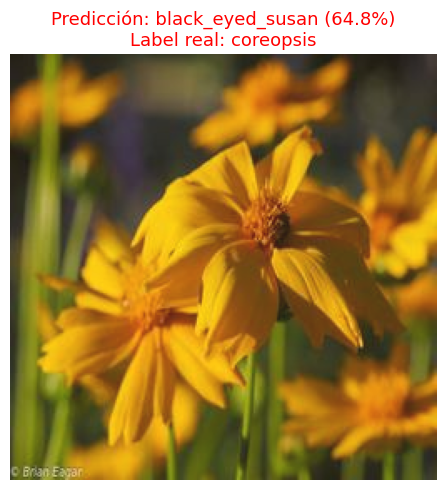

In [ ]:
images, labels = next(iter(test_ds))

idx = 0

img = images[idx].numpy()
true_label = class_names[labels[idx].numpy()]

pred = model.predict(tf.expand_dims(images[idx], axis=0), verbose=0)
pred_label = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
color = 'green' if pred_label == true_label else 'red'
plt.title(
    f"Predicción: {pred_label} ({confidence:.1f}%)\nLabel real: {true_label}",
    color=color,
    fontsize=13
)
plt.tight_layout()
plt.show()

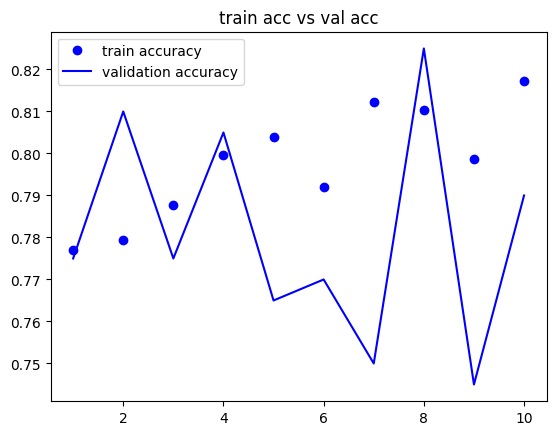

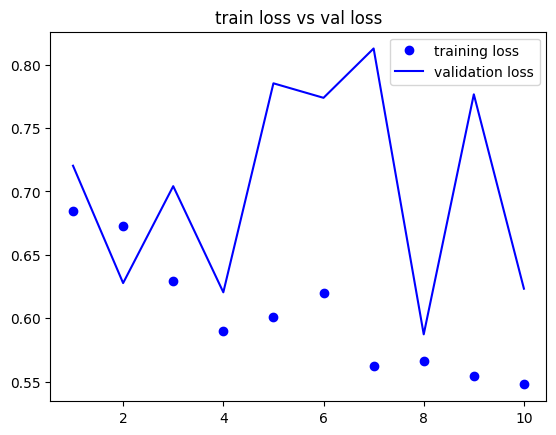

In [ ]:
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.plot(epochs,val_acc, 'b', label='validation accuracy')
plt.title('train acc vs val acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.plot(epochs,val_loss, 'b', label = 'validation loss')
plt.title('train loss vs val loss')
plt.legend()

plt.show()

                  precision    recall  f1-score   support

         astilbe       0.67      0.57      0.62         7
      bellflower       0.75      0.86      0.80         7
black_eyed_susan       0.71      0.71      0.71         7
       calendula       0.36      0.71      0.48         7
california_poppy       1.00      0.71      0.83         7
       carnation       0.57      0.57      0.57         7
    common_daisy       0.75      0.86      0.80         7
       coreopsis       1.00      0.43      0.60         7
       dandelion       1.00      1.00      1.00         7
            iris       1.00      0.86      0.92         7
            rose       0.86      0.86      0.86         7
       sunflower       0.88      1.00      0.93         7
           tulip       1.00      0.86      0.92         7
      water_lily       1.00      0.86      0.92         7

        accuracy                           0.78        98
       macro avg       0.82      0.78      0.78        98
    weighted

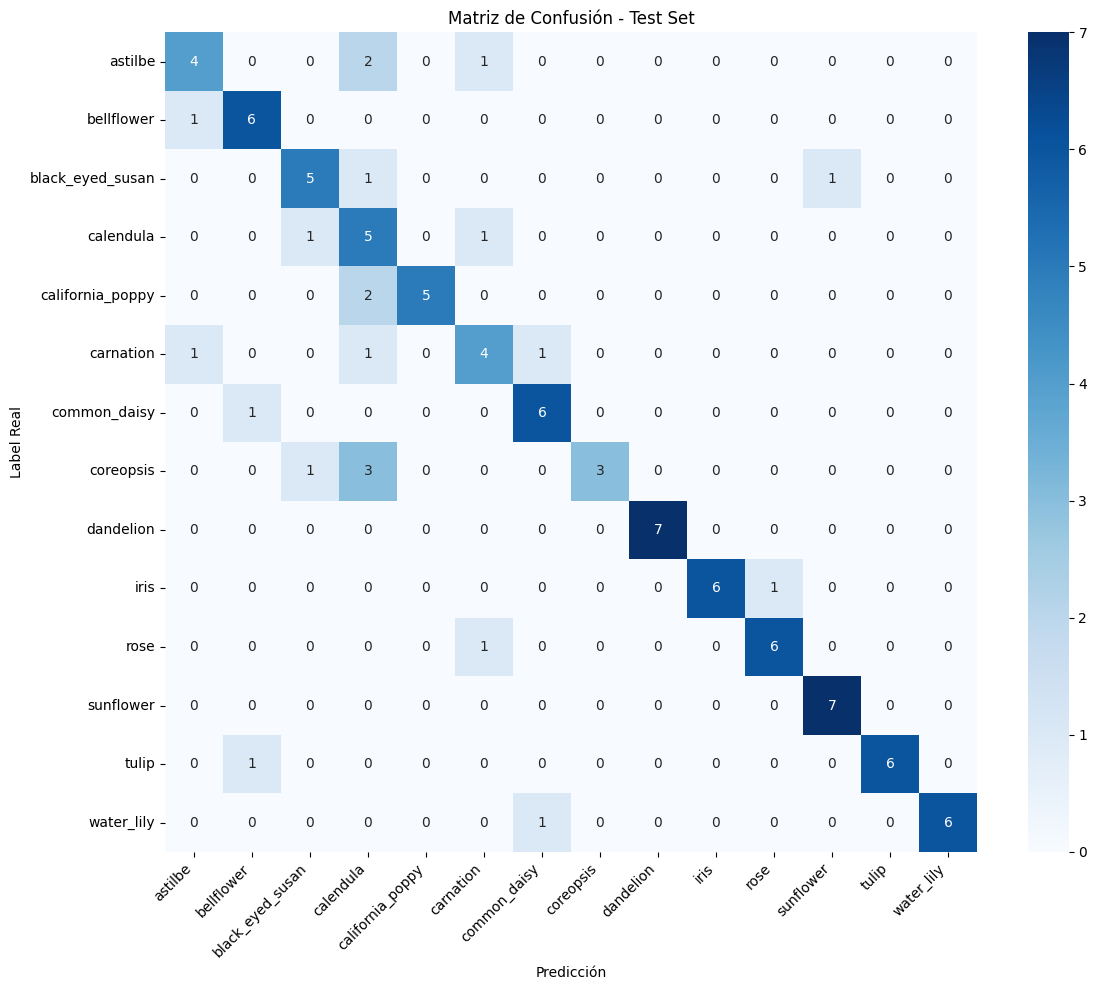

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Test Set')
plt.ylabel('Label Real')
plt.xlabel('Predicción')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Uso


In [ ]:
def predict_folder_like_testds(folder_path, model, class_names):

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"Found image files in {folder_path}: {image_files}")

    for file in image_files:
        img_path = os.path.join(folder_path, file)

        img = tf.keras.utils.load_img(
            img_path,
            target_size=(256, 256)
        )
        img = tf.keras.utils.img_to_array(img)
        img_norm = img / 255.0

        pred = model.predict(
            tf.expand_dims(img_norm, axis=0),
            verbose=0
        )

        pred_label = class_names[np.argmax(pred)]
        confidence = np.max(pred) * 100

        plt.figure(figsize=(5, 5))
        plt.imshow(img.astype("uint8"))
        plt.axis('off')
        plt.title(
            f"{file}\nPredicción: {pred_label} ({confidence:.1f}%)",
            fontsize=13
        )
        plt.tight_layout()
        plt.show()


In [ ]:
input_folder = "/content/drive/MyDrive/8vo/data/Flowers/usage"
output_folder = "/content/drive/MyDrive/8vo/data/Flowers/usage"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(input_folder, file)

        img = tf.keras.utils.load_img(
            img_path,
            target_size=(256, 256)
        )

        save_path = os.path.join(output_folder, file)
        #img = tf.image.rot90(img, k=3)
        tf.keras.utils.save_img(save_path, img)

print("Todas las imágenes fueron forzadas a 256x256 y guardadas.")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Todas las imágenes fueron forzadas a 256x256 y guardadas.


Checking folder: /content/drive/MyDrive/8vo/data/Flowers/usage
All files found in /content/drive/MyDrive/8vo/data/Flowers/usage: ['pngtree-realistic-red-rose-white-background-png-image_11716749.png', 'ivan-jevtic-p7mo8-CG5Gs-unsplash-2-scaled.jpg', "Rosa_'Ambiente',_Bad_Wörishofen,_Alemania,_2019-06-20,_DD_25.jpg"]
Found image files in /content/drive/MyDrive/8vo/data/Flowers/usage: ['pngtree-realistic-red-rose-white-background-png-image_11716749.png', 'ivan-jevtic-p7mo8-CG5Gs-unsplash-2-scaled.jpg', "Rosa_'Ambiente',_Bad_Wörishofen,_Alemania,_2019-06-20,_DD_25.jpg"]


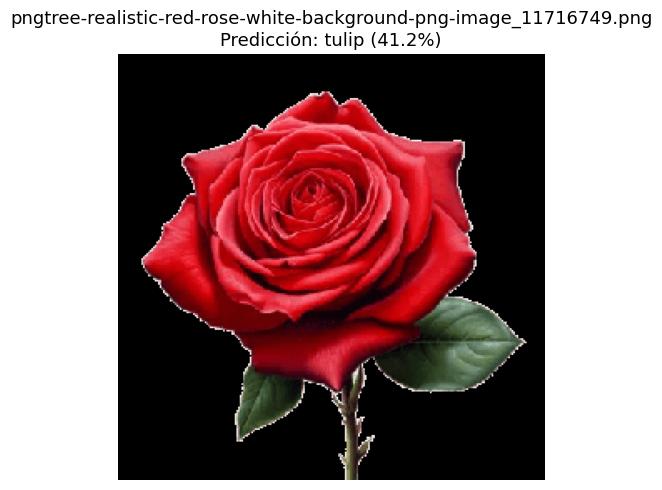

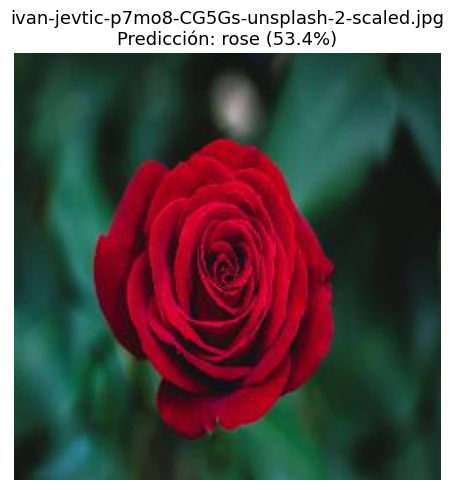

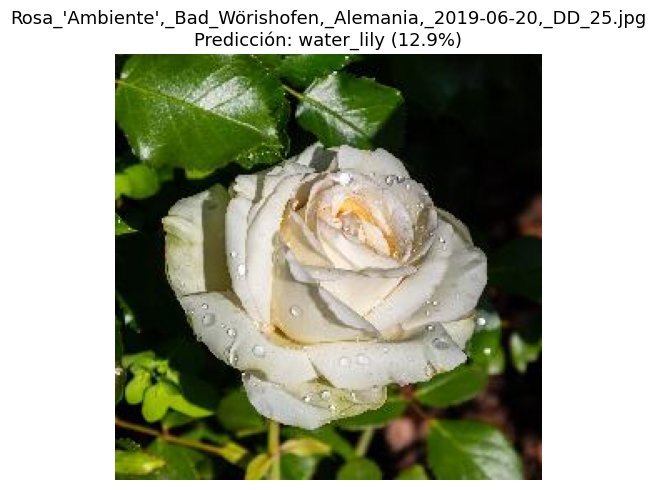

In [ ]:

folder_path = "/content/drive/MyDrive/8vo/data/Flowers/usage"

print(f"Checking folder: {folder_path}")
if not os.path.exists(folder_path):
    print(f"Error: Folder does not exist at {folder_path}")
elif not os.path.isdir(folder_path):
    print(f"Error: Path is not a directory at {folder_path}")
else:
    all_files_in_folder = os.listdir(folder_path)
    print(f"All files found in {folder_path}: {all_files_in_folder}")
    predict_folder_like_testds(
        folder_path=folder_path,
        model=bettermodel,
        class_names=class_names
    )
